In [1]:
%load_ext autoreload
%autoreload 2

In [19]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import functools
from torch.optim import Adam
import matplotlib.pyplot as plt
import tqdm
import copy

from torch.utils.data import DataLoader, Dataset

# added by Taos
from einops import rearrange
import pandas as pd
import seaborn as sns
import lightning.pytorch as pl
pl.seed_everything(2376999025)
sns.set_theme(style='whitegrid', font_scale=1.5, palette=sns.color_palette('husl'),)
from dafm import plots


Seed set to 2376999025


In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [4]:
# model
# Defining a time-dependent score-based model

class GaussianFourierProjection(nn.Module):
    """Gaussian random features for encoding time steps."""
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        # Randomly sample weights during initialization. These weights are fixed
        # during optimization and are not trainable.
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class ScoreNet(nn.Module):
    """A time-dependent score-based model built upon U-Net architecture."""

    def __init__(self, marginal_prob_std, x_dim , hidden_depth=2, embed_dim=128, use_bn=True):
        """Initialize a time-dependent score-based network.

        Args:
          marginal_prob_std: A function that takes time t and gives the standard
            deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
          channels: The number of channels for feature maps of each resolution.
          embed_dim: The dimensionality of Gaussian random feature embeddings.
        """
        super().__init__()
        self.x_dim = x_dim
        self.hidden_depth = hidden_depth
        self.embed_dim = embed_dim
        self.use_bn = use_bn

        assert hidden_depth>=1, 'hidden_depth must be greater than 0!'
        # Gaussian random feature embedding layer for time
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
             nn.Linear(embed_dim, embed_dim))

        # fc layers
        self.input = nn.Linear(x_dim, embed_dim)
        self.fc_all = nn.ModuleList([nn.Linear(embed_dim, embed_dim) for i in range(self.hidden_depth)])
        self.output = nn.Linear(embed_dim, x_dim)

        if self.use_bn:
            self.bn = nn.ModuleList([nn.BatchNorm1d(num_features=embed_dim) for i in range(self.hidden_depth)])

        # The swish activation function
        self.act = lambda x: x * torch.sigmoid(x)
        self.marginal_prob_std = marginal_prob_std


    def forward(self, x, t):
        # Obtain the Gaussian random feature embedding for t
        embed = self.act(self.embed(t))

        #
        h = self.input(x)
        # residue connections
        for i in range(self.hidden_depth):
            h = h + self.act(self.fc_all[i](h)) + embed
            if self.use_bn:
                h = self.bn[i](h)

        h = self.output(h)

        # Normalize output
        h = h / self.marginal_prob_std(t)[:, None,]
        return h


# Define the loss function
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
    """The loss function for training score-based generative models.

    Args:
    model: A PyTorch model instance that represents a
      time-dependent score-based model.
    x: A mini-batch of training data.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    eps: A tolerance value for numerical stability.
    """
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps #(eps,1)
    z = torch.randn_like(x)
    std = marginal_prob_std(random_t)
    perturbed_x = x + z * std[:, None]
    score = model(perturbed_x, random_t)
    loss = torch.mean(torch.sum((score * std[:, None] + z)**2, dim=1))
    return loss


def marginal_prob_std(t, sigma):
    """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.

    Args:
    t: A vector of time steps.
    sigma: The $\sigma$ in our SDE.

    Returns:
    The standard deviation.
    """
    # t = torch.tensor(t, device=device)
    return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))


def diffusion_coeff(t, sigma):
    """Compute the diffusion coefficient of our SDE.

    Args:
    t: A vector of time steps.
    sigma: The $\sigma$ in our SDE.

    Returns:
    The vector of diffusion coefficients.
    """
    # return torch.tensor(sigma**t, device=device)
    return sigma**t


# data set
class MyDataset(Dataset):
    def __init__(self, x_train):
        super().__init__()
        self.x_train = x_train

    def __len__(self):
        return self.x_train.shape[0]

    def __getitem__(self, idx):
        return self.x_train[idx]



def train_model(score_model, x_sample, lr=1e-4, batch_size=1000, n_epochs=5000, print_interval=100):
    dataset = MyDataset(x_sample)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = Adam(score_model.parameters(), lr=lr)
    train_loss = []


    for epoch in range(n_epochs):
        avg_loss = 0.
        num_items = 0
        for x in data_loader:
            x = x.to(device)
            loss = loss_fn(score_model, x, marginal_prob_std_fn)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            avg_loss += loss.item() * x.shape[0]
            num_items += x.shape[0]
        # Print the averaged training loss so far.
        epoch_avg_loss = avg_loss / num_items
        train_loss.append(epoch_avg_loss)
        if epoch%print_interval==0:
            print(f'epoch: {epoch}\t loss: {epoch_avg_loss}')
    return train_loss


def Euler_Maruyama_sampler(score_prior, marginal_prob_std, diffusion_coeff, score_likelihood=None,
                           batch_size=64,num_steps=500,device='cpu',eps=1e-3):
    """Generate samples from score-based models with the Euler-Maruyama solver.

    Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that gives the standard deviation of
    the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
    Equivalent to the number of discretized time steps.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    eps: The smallest time step for numerical stability.

    Returns:
    Samples.
    """
    t = torch.ones(batch_size, device=device)
    init_x = torch.randn(batch_size, score_prior.x_dim, device=device) \
    * marginal_prob_std(t)[:, None]
    time_steps = torch.linspace(1., eps, num_steps, device=device)
    step_size = time_steps[0] - time_steps[1]
    x = init_x
    with torch.no_grad():
        for time_step in tqdm.tqdm(time_steps):
            batch_time_step = torch.ones(batch_size, device=device) * time_step
            g = diffusion_coeff(batch_time_step)
            if score_likelihood is None:
                score = score_prior(x, batch_time_step)
            else:
                score = score_prior(x, batch_time_step) + score_likelihood(x)*torch.relu(1-2*time_step)

            # score = torch.clip(score, min=-100, max=100)

            score_norm = torch.sqrt(torch.mean(score**2, dim=1))
            adj_ratio = torch.ones_like(score_norm)
            tol = 50.
            adj_ratio[score_norm>tol] = tol/score_norm[score_norm>tol]
            # score_norm = torch.clip(score_norm, min=0, max=50)


            score = score*adj_ratio[:,None]

            # print(time_step, score)

            mean_x = x + (g**2)[:, None] * score * step_size
            x = mean_x + torch.sqrt(step_size) * g[:, None] * torch.randn_like(x)
        # Do not include any noise in the last sampling step.
    return mean_x


In [5]:
# diffusion setup
device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
sigma =  25.0#@param {'type':'number'}
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)


In [6]:
# define obs system
# h(x) = x^3



# def likelihood_1d(x, obs, sigma_obs):
#     return torch.exp(-0.5*(x**3 - obs)**2/sigma_obs**2)

def likelihood_score_1d(x, obs, sigma_obs):
    temp1 = -(x - obs)/sigma_obs**2
    temp2 = 1
    return temp2*temp1


# def likelihood(x, obs, sigma_obs):
#     l1 = likelihood_1d(x[:,0], obs[0], sigma_obs)
#     l2 = likelihood_1d(x[:,1], obs[1], sigma_obs)
#     return l1*l2

def likelihood_score(x, obs, sigma_obs):
    score_d = []
    for d in range(num_dim):
        score_d.append(likelihood_score_1d(x[:,d], obs[d], sigma_obs))
        #score_d[d] = likelihood_score_1d(x[:,d], obs[0], sigma_obs)
    
    sc = torch.stack(score_d, dim=1)
    return sc

# def likelihood_score_damp(x, obs, sigma_obs, c=0.01):
#     sc1 = likelihood_score_1d(x[:,0], obs[0], sigma_obs)
#     sc2 = likelihood_score_1d(x[:,1], obs[1], sigma_obs)
#     sc = torch.stack([sc1, sc2], dim=1)
#     sc_gauss = -(x)/c

    # sc_norm = torch.mean(sc**2, dim=1)
    # gauss_norm = torch.mean(sc_gauss**2, dim=1)
    # sc[sc_norm > gauss_norm] = sc_gauss[sc_norm > gauss_norm]
    # return sc

# filtering setup

/tmp/ipykernel_33672/1816440704.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x_new[0] = x_old[0] - 4*x_old[0]*(x_old[0]**2 - 1)*dt + sigma_SDE*np.random.randn(1) * np.sqrt(dt)
/tmp/ipykernel_33672/1816440704.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  obs_path = obs_path_true + np.random.randn(N_T,num_dim)*sigma_obs


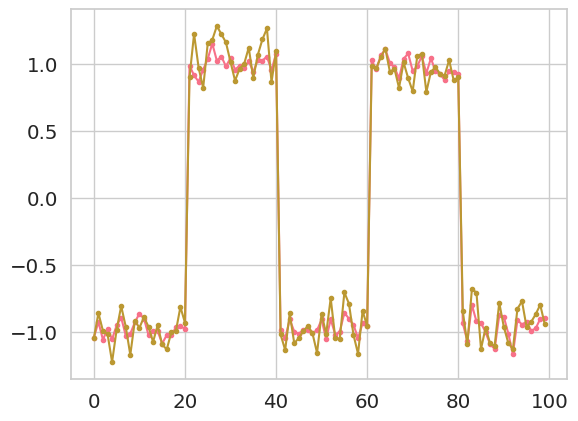

In [7]:
# Problem formulation
# state process setup
Time = 10.
dt = 0.1
num_dim = 1
X_initial = -1 + torch.randn(1) * 0.02
N_T = int(Time//dt+1)
t_path = np.linspace(0, Time, N_T)
sigma_SDE = 0.2


#dt = t_path[1] - t_path[0]


X_path = torch.zeros((N_T, num_dim))
X_path[0] = X_initial.clone()
x_new = X_initial.clone()

for i in range(N_T-1):
    # Generate true state trajectory
    x_old = X_path[i]
    
    x_new[0] = x_old[0] - 4*x_old[0]*(x_old[0]**2 - 1)*dt + sigma_SDE*np.random.randn(1) * np.sqrt(dt)
    
    X_path[i+1] = x_new
    
    if i==20:
        X_path[i+1] = -X_path[i+1]
    if i==40:
        X_path[i+1] = -X_path[i+1]
    if i==60:
        X_path[i+1] = -X_path[i+1]
    if i==80:
        X_path[i+1] = -X_path[i+1]
    
# plt.plot(*X_path.T, '.-')
# plt.title('state')
# plt.show()

# get observation
sigma_obs = 0.1

obs_path_true = X_path
obs_path = obs_path_true + np.random.randn(N_T,num_dim)*sigma_obs

# plot
plt.plot(X_path,'.-',label='state')
plt.plot(obs_path,'.-',label='obs')
plt.show()

In [8]:
# initial guess
x0 = torch.tensor(X_initial.clone(), dtype=torch.float32, device=device)
sigma0 = 0.2

print(X_initial)


/tmp/ipykernel_33672/252783346.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x0 = torch.tensor(X_initial.clone(), dtype=torch.float32, device=device)


tensor([-1.0427])


In [9]:
# Training initialize
x_dim = num_dim
hidden_depth  = 2
embed_dim = 50
use_bn = False

score_prior_old = ScoreNet(marginal_prob_std=marginal_prob_std_fn, x_dim=x_dim,
                           hidden_depth=hidden_depth, embed_dim=embed_dim, use_bn=use_bn)

score_prior_new = ScoreNet(marginal_prob_std=marginal_prob_std_fn, x_dim=x_dim,
                           hidden_depth=hidden_depth, embed_dim=embed_dim, use_bn=use_bn)

score_prior_old = score_prior_old.to(device)
score_prior_new = score_prior_new.to(device)

# initial samples
sample_size = 1000
x_init = x0 + torch.randn(sample_size,num_dim, dtype=torch.float32, device=device)*sigma0
train_loss = train_model(score_prior_old, x_sample=x_init, batch_size=sample_size, lr=0.005, n_epochs=600, print_interval=100)

likelihood_score_fn = None
score_prior_new = score_prior_old

epoch: 0	 loss: 1.4089938402175903
epoch: 100	 loss: 0.22517594695091248
epoch: 200	 loss: 0.08866260945796967
epoch: 300	 loss: 0.0702294409275055
epoch: 400	 loss: 0.0720125287771225
epoch: 500	 loss: 0.09543763846158981


In [10]:
est_all = []
x_prior = x_init.clone()
for i in range(N_T-1):
    print(i)
    
    score_prior_old = score_prior_new
    score_prior_new = copy.deepcopy(score_prior_new)
    
    # sample initial distribution
    x_init = Euler_Maruyama_sampler(score_prior_old,marginal_prob_std_fn, diffusion_coeff_fn,score_likelihood=likelihood_score_fn,
                                   batch_size=sample_size,num_steps=600,device=device)
    est_all.append(torch.mean(x_init, dim=0).cpu().numpy())


    # solve for forward SDE (prediction)
    x_prior[:,0] = x_init[:,0] - 4 * x_init[:,0] * ( x_init[:,0]**2 - 1)*dt + torch.randn(sample_size,device=device) * np.sqrt(dt)


    print('est: ',est_all[i])
    print('state: ',X_path[i])


    # train model for prior distribution
    train_loss = train_model(score_prior_new, x_sample=x_prior,
                             batch_size=sample_size,lr=0.01, n_epochs=600, print_interval=200)

    # new observation
    obs_current = np.array(obs_path[i+1,:])

    # update likelihood function
    likelihood_score_fn = functools.partial(likelihood_score, obs=obs_current, sigma_obs=sigma_obs)
    # likelihood_score_fn = functools.partial(likelihood_score_damp, obs=obs_current, sigma_obs=sigma_obs, c=0.1)
    # next iteration


# last estimation
# sample initial distribution
x_init = Euler_Maruyama_sampler(score_prior_old,marginal_prob_std_fn, diffusion_coeff_fn,score_likelihood=likelihood_score_fn,
                               batch_size=sample_size,num_steps=500,device=device)
est_all.append(torch.mean(x_init, dim=0).cpu().numpy())

#
est_all = np.array(est_all)


0


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:00<00:00, 760.10it/s]


est:  [-1.0913011]
state:  tensor([-1.0427])
epoch: 0	 loss: 0.17781862616539001
epoch: 200	 loss: 0.15668553113937378
epoch: 400	 loss: 0.1781744509935379
1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:00<00:00, 633.70it/s]


est:  [-0.8847273]
state:  tensor([-0.9261])
epoch: 0	 loss: 0.13646838068962097
epoch: 200	 loss: 0.13975539803504944
epoch: 400	 loss: 0.14230363070964813
2


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:00<00:00, 674.36it/s]


est:  [-0.8831089]
state:  tensor([-0.9745])
epoch: 0	 loss: 0.12353155016899109
epoch: 200	 loss: 0.12723684310913086
epoch: 400	 loss: 0.11891243606805801
98


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:00<00:00, 671.05it/s]


est:  [-0.8083532]
state:  tensor([-0.9036])
epoch: 0	 loss: 0.15620304644107819
epoch: 200	 loss: 0.13411575555801392
epoch: 400	 loss: 0.11407192051410675


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 707.98it/s]


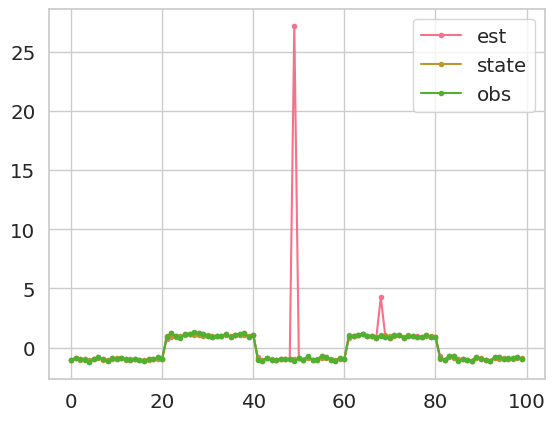

In [11]:
plt.plot(est_all,'.-',label='est')
plt.plot(X_path,'.-',label='state')
plt.plot(obs_path,'.-',label='obs')
plt.legend()
plt.show()

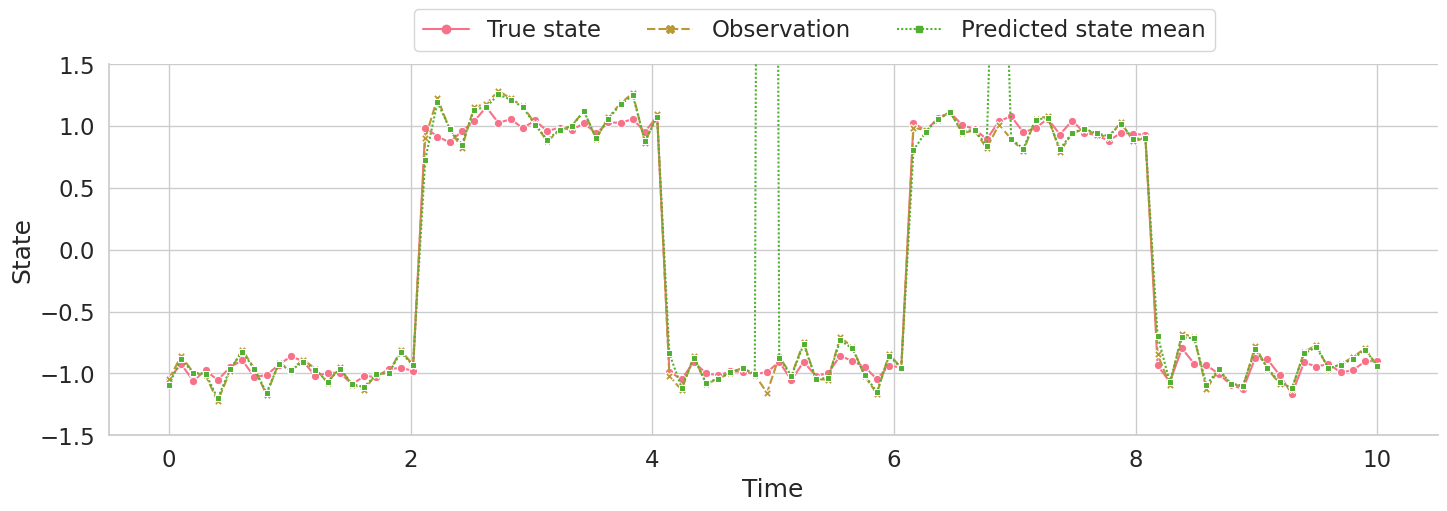

In [20]:
# added by Taos
df = (
    pd.DataFrame({
        k: rearrange(v, 't s -> (t s)')
        for k, v in {'Time': t_path[:, None], 'True state': X_path, 'Observation': obs_path, 'Predicted state mean': est_all}.items()
    })
)
# df['Predicted (sub) True'] = df['Predicted state mean'] - df['True state']
# df['Predicted (sub) Observation'] = df['Predicted state mean'] - df['Observation']
df = df.melt(id_vars='Time', var_name='Source', value_name='State')
df['IsResidual'] = False
# df.loc[df['Source'].str.contains('(sub)', regex=False), 'IsResidual'] = True
plot = (
    sns.relplot(
        data=df,
        kind='line',
        x='Time',
        y='State',
        # row='IsResidual',
        hue='Source',
        style='Source',
        markers=True,
        height=5,
        aspect=3,
        facet_kws=dict(
            sharey=False,
        ),
    )
    .set_titles('')
    .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(df['Source'].unique()),
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)
plot.tight_layout()

In [21]:
plots.save_all_subfigures(plot, 'DoubleWell')

In [ ]:
# np.savetxt('Est_all.txt', est_all)
# np.savetxt('X_path.txt', X_path)
# np.savetxt('obs_path.txt', obs_path)
